In [27]:
import numpy as np
import open3d as o3d
import os

def load_pcd_from_txt(file_path, color):
    # Load coordinates with your semicolon delimiter
    points = np.loadtxt(file_path, delimiter=';')
    
    # Create Open3D PointCloud object
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(points)
    
    # Apply uniform color
    pcd.paint_uniform_color(color)
    return pcd

def visualize_comparison(folder_path):
    # 1. Define Paths
    gt_path = os.path.join(folder_path, 'gt.txt')
    vis_path = os.path.join(folder_path, 'vis.txt')
    dense_path = os.path.join(folder_path, 'dense_points.txt')

    # 2. Load and Color (RGB format, values 0 to 1)
    # Green for Ground Truth, Red for Visible (Masked), Blue for Reconstruction
    pcd_gt = load_pcd_from_txt(gt_path, [0.1, 0.8, 0.1])    
    pcd_vis = load_pcd_from_txt(vis_path, [0.8, 0.1, 0.1])   
    pcd_dense = load_pcd_from_txt(dense_path, [0.1, 0.1, 0.8]) 

    # 3. Translate objects to sit side-by-side
    # We move them along the X-axis so they don't overlap
    offset = 2  # Adjust this based on your object scale
    pcd_vis.translate([offset, 0, 0])
    pcd_dense.translate([offset * 2, 0, 0])

    # 4. Create Coordinate Frame for orientation reference
    axis = o3d.geometry.TriangleMesh.create_coordinate_frame(size=0.5)

    # 5. Visualize
    print(f"Visualizing side-by-side comparison from: {folder_path}")
    print("Green: GT | Red: Visible | Blue: Reconstruction")
    o3d.visualization.draw_geometries([pcd_gt, pcd_vis, pcd_dense, axis], 
                                      window_name="Point-MAE Comparison: GT - VIS - DENSE")

# --- EXECUTION ---
# Change this to whichever sample folder you want to inspect
target_folder = 'C:/Users/tcnguyen/Downloads/Python code/Point-MAE-main/vis/custom_4' 
visualize_comparison(target_folder)

Visualizing side-by-side comparison from: C:/Users/tcnguyen/Downloads/Python code/Point-MAE-main/vis/custom_4
Green: GT | Red: Visible | Blue: Reconstruction


2D Overlay plot saved as: overlay_2d_custom_4.png


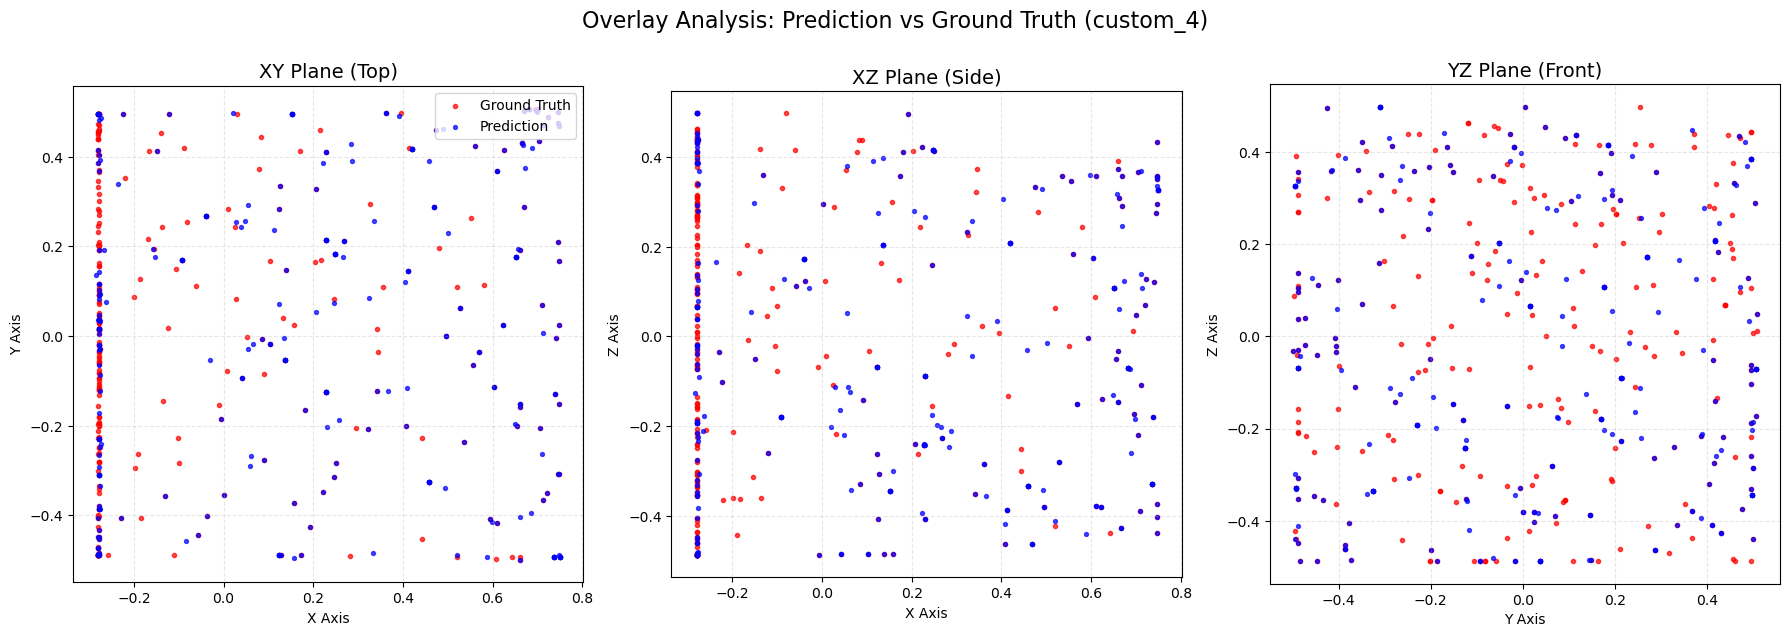

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import os

def plot_2d_overlay(folder_path):
    # 1. Define file paths
    gt_file = os.path.join(folder_path, 'gt.txt')
    pred_file = os.path.join(folder_path, 'dense_points.txt')
    
    if not os.path.exists(gt_file) or not os.path.exists(pred_file):
        print("Error: Missing gt.txt or dense_points.txt")
        return

    # 2. Load data (semicolon delimiter)
    gt_data = np.loadtxt(gt_file, delimiter=';')
    pred_data = np.loadtxt(pred_file, delimiter=';')

    # Define the planes: (X-index, Y-index, Title, X-label, Y-label)
    planes = [
        (0, 1, "XY Plane (Top)", "X", "Y"),
        (0, 2, "XZ Plane (Side)", "X", "Z"),
        (1, 2, "YZ Plane (Front)", "Y", "Z")
    ]

    # 3. Setup Figure (1 row, 3 columns)
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    for i, (idx_a, idx_b, title, lbl_a, lbl_b) in enumerate(planes):
        ax = axes[i]
        
        # Plot Ground Truth (Grey background)
        ax.scatter(gt_data[:, idx_a], gt_data[:, idx_b], 
                   color='red', s=9, alpha=0.7, label='Ground Truth')
        
        # Plot Prediction (Blue foreground)
        ax.scatter(pred_data[:, idx_a], pred_data[:, idx_b], 
                   color='blue', s=8, alpha=0.7, label='Prediction')

        ax.set_title(title, fontsize=14)
        ax.set_xlabel(f"{lbl_a} Axis")
        ax.set_ylabel(f"{lbl_b} Axis")
        ax.set_aspect('equal', adjustable='box')
        ax.grid(True, linestyle='--', alpha=0.3)
        
        if i == 0:
            ax.legend(loc='upper right')

    plt.suptitle(f"Overlay Analysis: Prediction vs Ground Truth ({os.path.basename(folder_path)})", 
                 fontsize=16, y=1.02)
    plt.tight_layout()
    
    output_name = f"overlay_2d_{os.path.basename(folder_path)}.png"
    plt.savefig(output_name, bbox_inches='tight', dpi=150)
    print(f"2D Overlay plot saved as: {output_name}")
    plt.show()

# --- EXECUTION ---
target_sample =  'C:/Users/tcnguyen/Downloads/Python code/Point-MAE-main/vis/custom_4' 
plot_2d_overlay(target_sample)

Sample 4 | Centroid: [-171.89822388   -0.78005505  -21.05250168] | Scale: 203.26950073242188


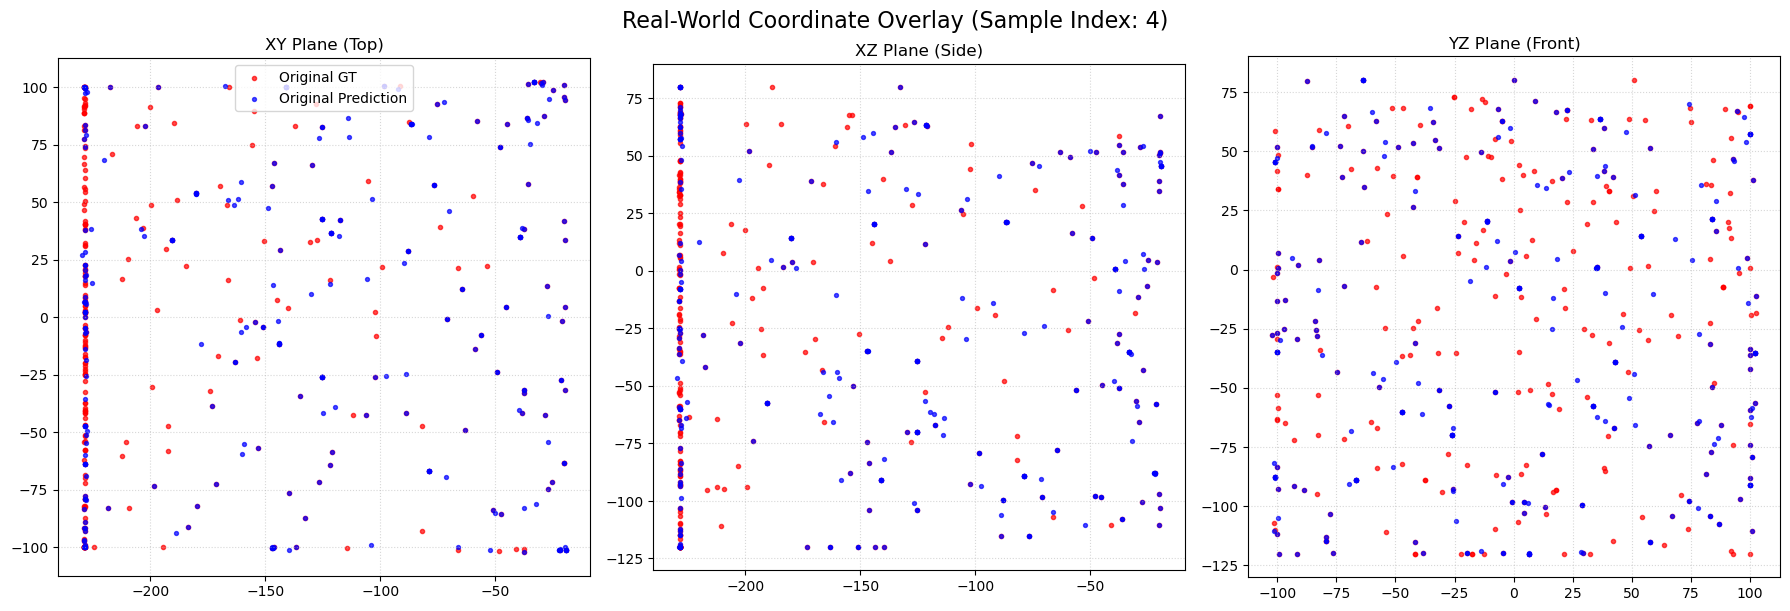

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import os

def visualize_original_coordinates(sample_index, folder_path, h5_path):
    # 1. Load the Recovery Parameters (Centroid and Scale) from H5
    with h5py.File(h5_path, 'r') as f:
        # Fetch the specific parameters for this sample
        centroid = f['centroid'][sample_index]  # Shape (3,)
        max_dist = f['max_dist'][sample_index]  # Scalar
    
    print(f"Sample {sample_index} | Centroid: {centroid} | Scale: {max_dist}")

    # 2. Load the Normalized Results from your vis folder
    gt_file = os.path.join(folder_path, 'gt.txt')
    pred_file = os.path.join(folder_path, 'dense_points.txt')
    
    # Load normalized coordinates (semicolon delimiter)
    gt_norm = np.loadtxt(gt_file, delimiter=';')
    pred_norm = np.loadtxt(pred_file, delimiter=';')

    # 3. Apply the Reverse Transformation
    # Formula: Original = (Normalized * Scale) + Centroid
    gt_orig = (gt_norm * max_dist) + centroid
    pred_orig = (pred_norm * max_dist) + centroid

    # 4. Plot in 2D (XY, XZ, YZ)
    planes = [(0, 1, "XY Plane (Top)"), (0, 2, "XZ Plane (Side)"), (1, 2, "YZ Plane (Front)")]
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    for i, (idx_a, idx_b, title) in enumerate(planes):
        ax = axes[i]
        # Plot GT in grey, Prediction in blue
        ax.scatter(gt_orig[:, idx_a], gt_orig[:, idx_b], color='red', s=9, alpha=0.7, label='Original GT')
        ax.scatter(pred_orig[:, idx_a], pred_orig[:, idx_b], color='blue', s=8, alpha=0.7, label='Original Prediction')
        
        ax.set_title(title)
        ax.set_aspect('equal')
        ax.grid(True, linestyle=':', alpha=0.5)
        if i == 0: ax.legend()

    plt.suptitle(f"Real-World Coordinate Overlay (Sample Index: {sample_index})", fontsize=16)
    plt.tight_layout()
    plt.show()

# --- SETTINGS ---
# Index 4 corresponds to the 'custom_4' folder
SAMPLE_IDX = 4 
RESULTS_DIR = 'C:/Users/tcnguyen/Downloads/Python code/Point-MAE-main/vis/custom_4'
H5_FILE = 'C:/Users/tcnguyen/Downloads/Python code/Point-MAE-main/data/MyDataset/test_dataset_normalized.h5'

visualize_original_coordinates(SAMPLE_IDX, RESULTS_DIR, H5_FILE)